# LEGO VR — Merged Data Analysis Notebook

**Input:** one `<participant_id>_synced.csv` from `../data/merged/`  
**Output:** analysis tables and plots for one participant. No new preprocessing files are written.

### Pipeline overview
1. **Load** one already synchronized participant file from `data/merged`
2. **Validate schema** required analysis columns are present
3. **Filter analysis rows** remove missing `model_name` and training models `TM`
4. **Exclude invalid trials** remove unusable sessions.
5. **Summarize QC** using existing bad/interpolated flags from preprocessing
6. **Annotate eye events** add consecutive `saccade_id`, `fixation_id`, `event_duration_ms` and `fixation_target`.
7. **Plots** fixation/saccade durations, grabs, match rates, and angular velocity trace

### Important upstream assumptions
The following steps are already handled by earlier notebooks and are **not recomputed here**:
- eye/body sampling-rate checks
- eye/body interpolation
- gaze angular velocity
- MAD thresholding
- fixation/saccade sample classification
- eye/body synchronization


# 1. Imports & Configuration

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")

DATA_DIR = Path("../data/merged")
PARTICIPANT_ID = "001"

FILE_PATH = DATA_DIR / f"{PARTICIPANT_ID}_synced.csv"

REQUIRED_COLUMNS = [
    "participant_id",
    "condition_number",
    "trial_number",
    "raw_timestamp",
    "time_ms",
    "event_type",
    "angular_velocity",
    "mad_threshold",
    "hit_obj_name",
    "LeftHand_grabbed_name",
    "RightHand_grabbed_name",
]

GROUP_COLS = ["participant_id", "condition_number", "trial_number"]
LEFT_GRABBED_COL = "LeftHand_grabbed_name"
RIGHT_GRABBED_COL = "RightHand_grabbed_name"


# 2. Data Loading & Schema Check

In [2]:
def list_available_participants(data_dir=DATA_DIR):
    return sorted(path.stem.replace("_synced", "") for path in data_dir.glob("*_synced.csv"))


def load_synced_participant(participant_id=PARTICIPANT_ID, data_dir=DATA_DIR):
    participant_id = str(participant_id).zfill(3)
    file_path = data_dir / f"{participant_id}_synced.csv"
    if not file_path.exists():
        available = ", ".join(list_available_participants(data_dir))
        raise FileNotFoundError(
            f"Missing synced file: {file_path}\n"
            f"Available participants: {available}"
        )

    df = pd.read_csv(file_path, low_memory=False)
    if "participant_id" in df.columns:
        df["participant_id"] = df["participant_id"].astype(str).str.zfill(3)
    return df, file_path


def validate_required_columns(df, required_columns=REQUIRED_COLUMNS):
    missing = [col for col in required_columns if col not in df.columns]
    if missing:
        raise KeyError("Missing required column(s): " + ", ".join(missing))
    return True


df_raw, file_path = load_synced_participant(PARTICIPANT_ID)
validate_required_columns(df_raw)

print(f"Loaded: {file_path}")
print(f"Shape : {df_raw.shape[0]:,} rows x {df_raw.shape[1]:,} columns")
print(f"Participant IDs: {sorted(df_raw['participant_id'].dropna().astype(str).unique())}")
print(f"Conditions     : {sorted(df_raw['condition_number'].dropna().unique())}")
print(f"Trials         : {sorted(df_raw['trial_number'].dropna().unique())[:20]}")

df_raw.head(3)


Loaded: ../data/merged/001_synced.csv
Shape : 646,964 rows x 141 columns
Participant IDs: ['001']
Conditions     : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Trials         : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
0,1000000972356065800,1778059755031,83.28207,0.782032,130142,1.0,Valid,0.024471,0.236849,0.971238,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1000000972361063200,1778059755040,83.28207,0.780995,130143,1.0,Valid,0.024434,0.236810,0.971249,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1000000972366064600,1778059755040,83.28207,0.779816,130144,1.0,Valid,0.024407,0.236764,0.971261,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 3. Analysis Cleaning

In [3]:
def cleaning_function(df: pd.DataFrame) -> pd.DataFrame:
    """
    Filter rows for analysis only.

    Removes rows where model_name is missing or marks a training model (contains "TM").
    This does not redo any preprocessing from earlier notebooks.
    """
    out = df.copy()
    model = out["model_name"].astype("string")
    keep = model.notna() & ~model.str.contains("TM", case=False, na=False)
    return out.loc[keep].copy()


n_before = len(df_raw)
df = cleaning_function(df_raw)
n_after = len(df)
removed = n_before - n_after
removed_pct = 100 * removed / n_before if n_before else 0

print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after cleaning : {n_after:,}")
print(f"Rows removed        : {removed:,} ({removed_pct:.2f}%)")

df.head(3)


Rows before cleaning: 646,964
Rows after cleaning : 354,382
Rows removed        : 292,582 (45.22%)


,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
119578,1000001886734534500,1778060668925,996.9191,2.0,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119579,1000001886739535200,1778060668925,996.9191,2.0,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119580,1000001886744543200,1778060668934,996.9284,2.0,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_RightFoot,is_interpolated_RightFoot,bad_sample_LeftFoot,is_interpolated_LeftFoot,bad_sample_Waist,is_interpolated_Waist,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand
119578,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119579,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119580,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119581,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
119582,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
642629,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
642630,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
642631,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
642632,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 4. Exclude invalid trials

In [4]:
def exclude_participant_models(df, participant_id, model_name):
    """
    Remove model(s) belonging to one participant.

    model_name:
        str          -> remove one model
        list[str]    -> remove multiple models
        None         -> remove the entire participant
    """
    participant_values = pd.to_numeric(
        df["participant_id"], errors="coerce"
    )
    target_participant = pd.to_numeric(
        pd.Series([participant_id]), errors="coerce"
    ).iloc[0]

    participant_mask = participant_values.eq(target_participant)

    if model_name is None:
        remove_mask = participant_mask
    else:
        models = [model_name] if isinstance(model_name, str) else model_name
        models = [str(model).strip().casefold() for model in models]

        model_mask = (
            df["model_name"]
            .astype("string")
            .str.strip()
            .str.casefold()
            .isin(models)
        )

        remove_mask = participant_mask & model_mask

    return df.loc[~remove_mask].copy()


# None means that the participant's entire session is excluded.
EXCLUSIONS = [
    ("013", "C3M4A"),
    ("016", ["C1M2A", "C2M1F"]),
    ("018", "C2M6A"),
    ("019", "C3M1F"),
    ("025", "C3M2A"),
    ("033", ["C3M1F", "C3M2A"]),
    ("035", "C3M6A"),
    ("037", "C3M4A"),
    ("038", "C1M5F"),
    ("041", "C2M2A"),
    ("043", "C3M1F"),
    ("044", ["C1M3F", "C1M2A", "C3M1F"]),
    ("047", ["C3M4A", "C3M5F"]),
    ("050", "C3M1F"),
    ("004", None),
    ("036", None),
]


rows_before = len(df)
exclusion_report = []

for participant_id, model_names in EXCLUSIONS:
    before = len(df)
    df = exclude_participant_models(
        df,
        participant_id=participant_id,
        model_name=model_names,
    )

    exclusion_report.append({
        "participant_id": participant_id,
        "model_name": (
            "ENTIRE SESSION"
            if model_names is None
            else ", ".join(model_names)
            if isinstance(model_names, list)
            else model_names
        ),
        "rows_removed": before - len(df),
    })

print(f"Rows before exclusions: {rows_before:,}")
print(f"Rows after exclusions:  {len(df):,}")
print(f"Total rows removed:     {rows_before - len(df):,}")

display(pd.DataFrame(exclusion_report))

Rows before exclusions: 354,382
Rows after exclusions:  354,382
Total rows removed:     0


,participant_id,model_name,rows_removed
0,013,C3M4A,0
1,016,"C1M2A, C2M1F",0
2,018,C2M6A,0
3,019,C3M1F,0
4,025,C3M2A,0
5,033,"C3M1F, C3M2A",0
6,035,C3M6A,0
7,037,C3M4A,0
8,038,C1M5F,0
9,041,C2M2A,0


# 5. Quality-Control Summary

In [6]:
def make_qc_summary(df):
    agg = {
        "n_samples": ("time_ms", "size"),
    }

    if "bad_sample" in df.columns:
        agg["n_bad"] = ("bad_sample", "sum")
    if "is_interpolated" in df.columns:
        agg["n_interpolated"] = ("is_interpolated", "sum")

    for col in sorted(c for c in df.columns if c.startswith("bad_sample_")):
        agg[f"n_{col}"] = (col, "sum")
    for col in sorted(c for c in df.columns if c.startswith("is_interpolated_")):
        agg[f"n_{col}"] = (col, "sum")

    summary = (
        df.groupby(["condition_number", "trial_number"], dropna=False)
        .agg(**agg)
        .reset_index()
    )

    if "n_bad" in summary.columns:
        summary["pct_bad"] = 100 * summary["n_bad"] / summary["n_samples"]
    if "n_interpolated" in summary.columns:
        summary["pct_interpolated"] = 100 * summary["n_interpolated"] / summary["n_samples"]

    return summary


qc_summary = make_qc_summary(df)
qc_summary.head(20)


,condition_number,trial_number,n_samples,n_bad,n_interpolated,n_bad_sample_LeftFoot,n_bad_sample_LeftHand,n_bad_sample_RightFoot,n_bad_sample_RightHand,n_bad_sample_Waist,n_is_interpolated_LeftFoot,n_is_interpolated_LeftHand,n_is_interpolated_RightFoot,n_is_interpolated_RightHand,n_is_interpolated_Waist,pct_bad,pct_interpolated
0,1,1,6820,232,352,0.0,153.0,0.0,35.0,270.0,0.0,213.0,0.0,67.0,330.0,3.401760,5.161290
1,1,2,6990,207,296,0.0,0.0,0.0,0.0,359.0,0.0,0.0,0.0,0.0,405.0,2.961373,4.234621
2,1,3,29675,731,1053,0.0,0.0,0.0,0.0,1794.0,0.0,0.0,0.0,0.0,1888.0,2.463353,3.548441
3,1,4,23014,711,1036,0.0,0.0,0.0,0.0,1019.0,0.0,0.0,0.0,0.0,1136.0,3.089424,4.501608
4,1,5,8968,417,609,0.0,0.0,0.0,0.0,192.0,0.0,0.0,0.0,0.0,261.0,4.649866,6.790812
5,1,6,14376,415,545,0.0,0.0,0.0,0.0,857.0,0.0,0.0,0.0,0.0,964.0,2.886756,3.791041
6,2,1,19533,425,601,0.0,327.0,0.0,516.0,506.0,0.0,441.0,0.0,664.0,597.0,2.175805,3.076844
7,2,2,42947,943,1247,151.0,416.0,0.0,9.0,1014.0,178.0,573.0,0.0,27.0,1167.0,2.195730,2.903579
8,2,3,7649,162,220,0.0,0.0,0.0,0.0,106.0,0.0,0.0,0.0,0.0,170.0,2.117924,2.876193
9,2,4,22404,521,682,0.0,0.0,0.0,0.0,686.0,0.0,0.0,0.0,0.0,784.0,2.325478,3.044099


# 6. Event Annotation

In [7]:
def add_saccade_fixation_ids(
    df,
    group_cols=GROUP_COLS,
    category_col="event_type",
    time_col="time_ms",
):
    """
    Add IDs for consecutive saccade and fixation runs.

    Output columns:
    - saccade_id
    - fixation_id
    - event_duration_ms
    """
    out = df.copy()
    out = out.sort_values(list(group_cols) + [time_col]).copy()

    out["saccade_id"] = pd.Series(index=out.index, dtype="Int64")
    out["fixation_id"] = pd.Series(index=out.index, dtype="Int64")
    out["event_duration_ms"] = np.nan

    saccade_counter = 0
    fixation_counter = 0

    for _, sub in out.groupby(list(group_cols), sort=False, dropna=False):
        sub = sub.sort_values(time_col)
        labels = sub[category_col].astype("string").tolist()
        times = pd.to_numeric(sub[time_col], errors="coerce").to_numpy(dtype=float)
        idx = sub.index.to_list()

        dt = np.diff(times)
        dt = dt[np.isfinite(dt) & (dt > 0)]
        median_dt = float(np.median(dt)) if len(dt) > 0 else np.nan

        run_start = 0
        for i in range(1, len(sub) + 1):
            if i == len(sub):
                run_ended = True
            else:
                curr_label = labels[i]
                start_label = labels[run_start]
                if pd.isna(curr_label) and pd.isna(start_label):
                    run_ended = False
                elif pd.isna(curr_label) or pd.isna(start_label):
                    run_ended = True
                else:
                    run_ended = curr_label != start_label

            if not run_ended:
                continue

            label = labels[run_start]
            run_idx = idx[run_start:i]
            n_rows = len(run_idx)

            if pd.notna(label) and n_rows > 0 and np.isfinite(median_dt):
                duration_ms = n_rows * median_dt
                out.loc[run_idx, "event_duration_ms"] = duration_ms

                if label == "saccade":
                    saccade_counter += 1
                    out.loc[run_idx, "saccade_id"] = saccade_counter
                elif label == "fixation":
                    fixation_counter += 1
                    out.loc[run_idx, "fixation_id"] = fixation_counter

            run_start = i

    return out.sort_index()


def add_fixation_target(
    df,
    fixation_col="fixation_id",
    hit_col="hit_obj_name",
    target_col="fixation_target",
    group_cols=None,
):
    """
    Add fixation_target as the most frequent hit_obj_name within each fixation.
    Ties are resolved by first appearance within the fixation.
    """
    out = df.copy()
    out[target_col] = pd.NA

    if group_cols is None:
        group_cols = [fixation_col]
    elif isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    valid = out[fixation_col].notna()

    def most_frequent_first_seen(s):
        s = s.dropna()
        if s.empty:
            return pd.NA
        counts = s.value_counts(sort=False)
        winners = set(counts[counts == counts.max()].index)
        for value in s:
            if value in winners:
                return value
        return pd.NA

    out.loc[valid, target_col] = (
        out.loc[valid]
        .groupby(group_cols, sort=False, dropna=False)[hit_col]
        .transform(most_frequent_first_seen)
    )

    return out


def add_grabbed_item_ids(
    df,
    left_col=LEFT_GRABBED_COL,
    right_col=RIGHT_GRABBED_COL,
    group_cols=GROUP_COLS,
    time_col="raw_timestamp",
):
    """Add consecutive grab IDs for left and right hands."""
    out = df.copy()
    sort_cols = [col for col in [*group_cols, time_col] if col in out.columns]
    group_cols = [col for col in group_cols if col in out.columns]

    out = out.sort_values(sort_cols).reset_index(drop=False)

    for hand, grabbed_col in [("lefthand", left_col), ("righthand", right_col)]:
        if grabbed_col not in out.columns:
            raise KeyError(f"Missing grabbed-object column: {grabbed_col}")

        grab_id_col = f"{hand}_grab_id"
        grabbed = out[grabbed_col].astype("string")
        is_grabbing = grabbed.notna() & grabbed.ne("") & grabbed.str.lower().ne("nan")

        previous = grabbed.groupby([out[col] for col in group_cols], dropna=False).shift()
        changed_object = grabbed.ne(previous)
        new_grab = is_grabbing & changed_object

        out[grab_id_col] = new_grab.cumsum()
        out.loc[~is_grabbing, grab_id_col] = pd.NA
        out[grab_id_col] = out[grab_id_col].astype("Int64")

    return out.sort_values("index").drop(columns="index").reset_index(drop=True)


df = add_saccade_fixation_ids(df)
df = add_fixation_target(df, group_cols=[*GROUP_COLS, "fixation_id"])
df = add_grabbed_item_ids(df)

created_cols = [
    "saccade_id",
    "fixation_id",
    "event_duration_ms",
    "fixation_target",
    "lefthand_grab_id",
    "righthand_grab_id",
]
print("Created columns:")
for col in created_cols:
    print(f"  {col}: {col in df.columns}")

df[created_cols].head(10)


Created columns:
  saccade_id: True
  fixation_id: True
  event_duration_ms: True
  fixation_target: True
  lefthand_grab_id: True
  righthand_grab_id: True


,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id
0,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
1,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
2,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
3,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
4,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
5,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
6,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
7,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
8,<NA>,1,125.0176,Wall_Front,<NA>,<NA>
9,<NA>,1,125.0176,Wall_Front,<NA>,<NA>


In [25]:
df

,gaze_capture_time,raw_timestamp,relative_to_unix_epoch_timestamp,focus_distance,frame_number,stability,status,gaze_forward_x,gaze_forward_y,gaze_forward_z,...,bad_sample_LeftHand,is_interpolated_LeftHand,bad_sample_RightHand,is_interpolated_RightHand,saccade_id,fixation_id,event_duration_ms,fixation_target,lefthand_grab_id,righthand_grab_id
0,1000001886734534500,1778060668925,996.9191,2.000000,312947,0.683982,Valid,0.031344,0.294718,0.955070,...,0.0,0.0,0.0,0.0,<NA>,1,125.017600,Wall_Front,<NA>,<NA>
1,1000001886739535200,1778060668925,996.9191,2.000000,312948,0.682689,Valid,0.031658,0.294867,0.955014,...,0.0,0.0,0.0,0.0,<NA>,1,125.017600,Wall_Front,<NA>,<NA>
2,1000001886744543200,1778060668934,996.9284,2.000000,312949,0.749988,Valid,0.031943,0.294998,0.954964,...,0.0,0.0,0.0,0.0,<NA>,1,125.017600,Wall_Front,<NA>,<NA>
3,1000001886749543300,1778060668934,996.9284,2.000000,312950,0.851914,Valid,0.032383,0.294995,0.954950,...,0.0,0.0,0.0,0.0,<NA>,1,125.017600,Wall_Front,<NA>,<NA>
4,1000001886754542400,1778060668945,996.9396,2.000000,312951,1.000000,Valid,0.032786,0.294996,0.954936,...,0.0,0.0,0.0,0.0,<NA>,1,125.017600,Wall_Front,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354377,1000005088780099400,1778063870984,3723.7470,0.583587,953108,0.912354,Valid,0.229579,-0.162637,0.959606,...,0.0,0.0,0.0,0.0,<NA>,9099,985.138688,NextItemButton,<NA>,160
354378,1000005088785100000,1778063870984,3723.7470,0.583548,953109,0.906667,Valid,0.229546,-0.162617,0.959617,...,0.0,0.0,0.0,0.0,<NA>,9099,985.138688,NextItemButton,<NA>,160
354379,1000005088790100900,1778063870984,3723.7470,0.583413,953110,0.888851,Valid,0.229516,-0.162539,0.959637,...,0.0,0.0,0.0,0.0,<NA>,9099,985.138688,NextItemButton,<NA>,160
354380,1000005088795101500,1778063870984,3723.7470,0.583175,953111,0.873793,Valid,0.229448,-0.162440,0.959670,...,0.0,0.0,0.0,0.0,<NA>,9099,985.138688,NextItemButton,<NA>,160


# 7. Analysis Tables & Plots

In [19]:
def get_time_window(df, cond, trial, t_start_ms, t_end_ms):
    return df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
        & (df["time_ms"] >= t_start_ms)
        & (df["time_ms"] <= t_end_ms)
    ].copy()


def make_saccade_events(df):
    return (
        df.dropna(subset=["saccade_id"])
        .groupby(GROUP_COLS + ["saccade_id"], as_index=False, dropna=False)
        .agg(
            duration_ms=("event_duration_ms", "first"),
            start_time_ms=("time_ms", "min"),
            end_time_ms=("time_ms", "max"),
            peak_velocity=("angular_velocity", "max"),
        )
    )


def make_basic_counts(df):
    left_brick_grabs = df[
        df[LEFT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["lefthand_grab_id"].nunique()
    right_brick_grabs = df[
        df[RIGHT_GRABBED_COL].astype("string").str.contains("brick", case=False, na=False)
    ]["righthand_grab_id"].nunique()

    return pd.Series({
        "fixations": df["fixation_id"].nunique(),
        "saccades": df["saccade_id"].nunique(),
        "left_grabs": df["lefthand_grab_id"].nunique(),
        "right_grabs": df["righthand_grab_id"].nunique(),
        "left_brick_grabs": left_brick_grabs,
        "right_brick_grabs": right_brick_grabs,
    })


basic_counts = make_basic_counts(df)
saccade_events = make_saccade_events(df)

print("Basic counts")
print(basic_counts.to_string())
print("\nSaccade duration summary")
print(saccade_events["duration_ms"].describe().to_string())


Basic counts
fixations            9099
saccades             9084
left_grabs            100
right_grabs           161
left_brick_grabs       82
right_brick_grabs     145

Saccade duration summary
count    9084.000000
mean       59.405563
std        87.885633
min         5.000576
25%        10.001408
50%        40.005632
75%        65.007488
max      1050.147840


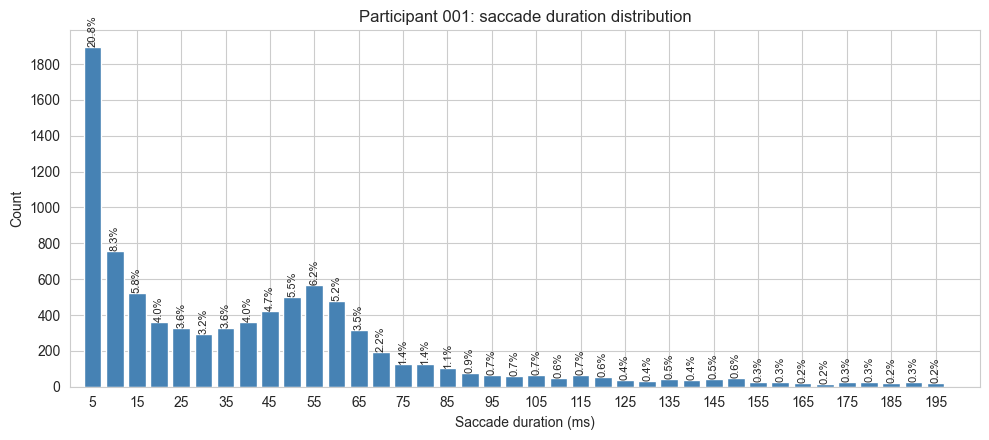

In [20]:
def plot_saccade_duration_histogram(saccade_events, min_ms=5, max_ms=200, bin_ms=5):
    plot_data = saccade_events[
        (saccade_events["duration_ms"] >= min_ms)
        & (saccade_events["duration_ms"] <= max_ms)
    ].copy()
    if plot_data.empty:
        print("No saccades in requested duration range.")
        return None

    plot_data["duration_bin"] = (bin_ms * (plot_data["duration_ms"] / bin_ms).round()).astype(int)
    duration_counts = plot_data["duration_bin"].value_counts().sort_index()
    total = len(saccade_events)

    fig, ax = plt.subplots(figsize=(10, 4.5))
    bars = ax.bar(duration_counts.index, duration_counts.values, width=bin_ms * 0.8, color="steelblue")

    for bar, count in zip(bars, duration_counts.values):
        pct = 100 * count / total if total else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

    ax.set_xlabel("Saccade duration (ms)")
    ax.set_ylabel("Count")
    ax.set_title(f"Participant {PARTICIPANT_ID}: saccade duration distribution")
    ax.set_xticks(np.arange(min_ms, max_ms + bin_ms, bin_ms * 2))
    ax.set_xlim(min_ms - bin_ms, max_ms + bin_ms)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    plt.tight_layout()
    return ax


plot_saccade_duration_histogram(saccade_events)
plt.show()


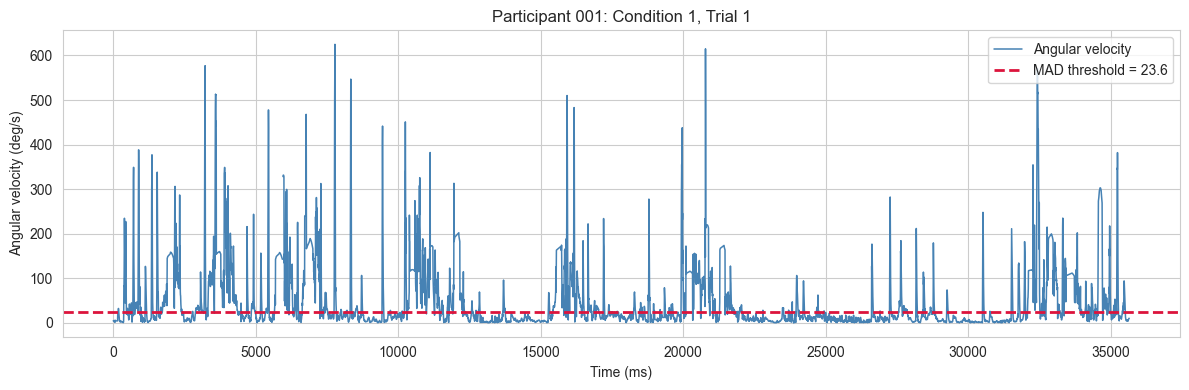

In [21]:
def plot_angular_velocity_trace(df, cond=1, trial=1, t_start_ms=None, t_end_ms=None):
    sub = df[
        (df["condition_number"] == cond)
        & (df["trial_number"] == trial)
    ].copy()
    if t_start_ms is not None:
        sub = sub[sub["time_ms"] >= t_start_ms]
    if t_end_ms is not None:
        sub = sub[sub["time_ms"] <= t_end_ms]

    sub["time_ms"] = pd.to_numeric(sub["time_ms"], errors="coerce")
    sub["angular_velocity"] = pd.to_numeric(sub["angular_velocity"], errors="coerce")
    threshold = pd.to_numeric(sub["mad_threshold"], errors="coerce").dropna()
    threshold = threshold.iloc[0] if not threshold.empty else np.nan

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(sub["time_ms"], sub["angular_velocity"], lw=1.1, color="steelblue", label="Angular velocity")
    if np.isfinite(threshold):
        ax.axhline(threshold, color="crimson", ls="--", lw=2, label=f"MAD threshold = {threshold:.1f}")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Angular velocity (deg/s)")
    ax.set_title(f"Participant {PARTICIPANT_ID}: Condition {cond}, Trial {trial}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    return ax


plot_angular_velocity_trace(df, cond=1, trial=1)
plt.show()


# 8. Final Objects

Main objects produced by this notebook:
- `df`: cleaned, annotated sample-level merged data for one participant
- `qc_summary`: condition/trial QC summary
- `saccade_events`: one row per saccade event
- `grab_fixation_matches`: one row per valid brick grab matched to previous template/model-brick fixation
